### Importación de librerías y configuración

In [18]:
# Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración visual para un EDA profesional
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (14, 7)

print("Librerías importadas y entorno configurado.")

Librerías importadas y entorno configurado.


### Carga de los Datos Originales

In [19]:
# Carga de los datasets crudos (Raw Data)
# Nota: Ajustamos ambos encodings a latin-1 para manejar tildes y eñes (característico de Datos Abiertos Colombia)
df_historico = pd.read_csv('eva_2007_2018.csv', sep=';', encoding='latin-1')
df_reciente = pd.read_csv('eva_2019_2024.csv', sep=';', encoding='latin-1')

print("Datasets cargados en memoria exitosamente.")

Datasets cargados en memoria exitosamente.


### Inspección INICIAL de los Datasets

In [20]:
def inspeccionar_dataset(df, nombre):
    print(f"\n{'='*50}")
    print(f"--- INSPECCIÓN INICIAL: {nombre} ---")
    print(f"{'='*50}")
    print(f"1. Dimensiones (Filas, Columnas): {df.shape}")
    print("\n2. Tipos de datos por columna:")
    print(df.dtypes)
    print("\n3. Cantidad de Valores Nulos (NA) por columna:")
    print(df.isna().sum())
    print("\n4. Duplicados exactos encontrados:", df.duplicated().sum())

# Ejecutamos la función para ambos
inspeccionar_dataset(df_historico, "DATASET HISTÓRICO (2007-2018)")
inspeccionar_dataset(df_reciente, "DATASET RECIENTE (2019-2024)")


--- INSPECCIÓN INICIAL: DATASET HISTÓRICO (2007-2018) ---
1. Dimensiones (Filas, Columnas): (210847, 17)

2. Tipos de datos por columna:
CÓD.DEP.                                          int64
DEPARTAMENTO                                     object
CÓD. MUN.                                         int64
MUNICIPIO                                        object
GRUPO DE CULTIVO                                 object
SUBGRUPO DE CULTIVO                              object
CULTIVO                                          object
DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO    object
AÑO                                               int64
PERIODO                                          object
Área Sembrada (ha)                               object
Área Cosechada (ha)                              object
Producción (t)                                   object
Rendimiento (t/ha)                               object
ESTADO FISICO PRODUCCION                         object
NOMBRE CIENTIFICO     

### Homologación y Unificación

In [21]:
# Estandarización de nombres de columnas para poder concatenar
cols_df_historico = {
    'CÓD.DEP.': 'Cod_Dep', 'DEPARTAMENTO': 'Departamento', 'CÓD. MUN.': 'Cod_Mun',
    'MUNICIPIO': 'Municipio', 'GRUPO DE CULTIVO': 'Grupo_Cultivo',
    'SUBGRUPO DE CULTIVO': 'Subgrupo_Cultivo', 'CULTIVO': 'Cultivo',
    'AÑO': 'Anio', 'PERIODO': 'Periodo', 'Área Sembrada (ha)': 'Area_Sembrada_ha',
    'Área Cosechada (ha)': 'Area_Cosechada_ha', 'Producción (t)': 'Produccion_t',
    'Rendimiento (t/ha)': 'Rendimiento_t_ha', 'CICLO DE CULTIVO': 'Ciclo_Cultivo'
}

cols_df_reciente = {
    'Código Dane departamento': 'Cod_Dep', 'Departamento': 'Departamento',
    'Código Dane municipio': 'Cod_Mun', 'Municipio': 'Municipio',
    'Grupo cultivo': 'Grupo_Cultivo', 'Subgrupo': 'Subgrupo_Cultivo',
    'Cultivo': 'Cultivo', 'Año': 'Anio', 'Periodo': 'Periodo',
    'Área sembrada (ha)': 'Area_Sembrada_ha', 'Área cosechada (ha)': 'Area_Cosechada_ha',
    'Producción (t)': 'Produccion_t', 'Rendimiento (t/ha)': 'Rendimiento_t_ha',
    'Ciclo del cultivo': 'Ciclo_Cultivo'
}

df_historico.rename(columns=cols_df_historico, inplace=True)
df_reciente.rename(columns=cols_df_reciente, inplace=True)

# Concatenación
columnas_finales = list(cols_df_historico.values())
df_unificado = pd.concat([df_historico[columnas_finales], df_reciente[columnas_finales]], ignore_index=True)

print(f"Bases de datos unificadas. Nuevo shape: {df_unificado.shape}")

Bases de datos unificadas. Nuevo shape: (351920, 14)


### Limpieza, Transformaciones (Semestre/Ciclo) e Imputación

In [22]:
# 1. Extraer Semestre y homogeneizar
df_unificado['Semestre'] = df_unificado['Periodo'].astype(str).str.extract(r'([AaBb])')[0].str.upper()
df_unificado['Semestre'] = df_unificado['Semestre'].fillna('ANUAL')

# 2. Homogeneizar Ciclo de Cultivo (Todo a TRANSITORIO o PERMANENTE)
df_unificado['Ciclo_Cultivo'] = df_unificado['Ciclo_Cultivo'].astype(str).str.upper().str.strip()
df_unificado['Ciclo_Cultivo'] = df_unificado['Ciclo_Cultivo'].replace('ANUAL', 'PERMANENTE')

# 3. Limpieza Numérica (Convertir comas europeas a puntos y cambiar a float)
cols_numericas = ['Area_Sembrada_ha', 'Area_Cosechada_ha', 'Produccion_t', 'Rendimiento_t_ha']
for col in cols_numericas:
    if df_unificado[col].dtype == 'object':
        df_unificado[col] = df_unificado[col].astype(str).str.replace(',', '.').astype(float)

# 4. IMPUTACIÓN DE NULOS
# Numéricas a 0 (Justificado agronómicamente como pérdida si se sembró pero no se cosechó)
df_unificado[cols_numericas] = df_unificado[cols_numericas].fillna(0)

# Categóricas a 'SIN INFORMACION'
cols_categoricas = df_unificado.select_dtypes(include=['object']).columns
df_unificado[cols_categoricas] = df_unificado[cols_categoricas].fillna('SIN INFORMACION')

print("Limpieza, Ingeniería de Características e Imputación completadas.")

Limpieza, Ingeniería de Características e Imputación completadas.


Homogeneización del campo Departamento

El campo `Departamento` proviene de dos fuentes con distintas convenciones de capitalización y caracteres especiales (tildes, eñes). Se aplica una normalización en dos pasos:
1. **Normalización de texto**: se eliminan tildes/diacríticos y se convierte todo a MAYÚSCULAS.
2. **Mapeo de variantes residuales**: se unifica el nombre largo del Archipiélago de San Andrés con su abreviatura histórica.

In [23]:
import unicodedata

# ─── Paso 1: Normalización de texto ───────────────────────────────────────────
# Eliminamos tildes/diacríticos y convertimos todo a MAYÚSCULAS sin espacios
# sobrantes. Esto unifica, por ejemplo:
#   'Valle del Cauca'  →  'VALLE DEL CAUCA'
#   'Boyacá'           →  'BOYACA'
#   'Córdoba'          →  'CORDOBA'

def normalizar_texto(texto):
    """Elimina tildes/diacríticos, pasa a mayúsculas y recorta espacios."""
    texto = str(texto).strip().upper()
    # Descompone el caracter en su base + diacrítico y filtra los diacríticos
    texto_normalizado = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto_normalizado

n_antes = df_unificado['Departamento'].nunique()
df_unificado['Departamento'] = df_unificado['Departamento'].apply(normalizar_texto)

# ─── Paso 2: Mapeo de variantes residuales ────────────────────────────────────
# Después de la normalización anterior queda una variante:
#   'ARCHIPIELAGO DE SAN ANDRES, PROVIDENCIA Y SANTA CATALINA'  (dataset reciente)
#   'SAN ANDRES Y PROVIDENCIA'                                   (dataset histórico)
# Unificamos ambas bajo el nombre canónico más corto.

mapeo_departamentos = {
    'ARCHIPIELAGO DE SAN ANDRES, PROVIDENCIA Y SANTA CATALINA': 'SAN ANDRES Y PROVIDENCIA',
}
df_unificado['Departamento'] = df_unificado['Departamento'].replace(mapeo_departamentos)

# ─── Reporte ──────────────────────────────────────────────────────────────────
n_despues = df_unificado['Departamento'].nunique()
print(f'Categorías únicas ANTES de homogeneizar: {n_antes}')
print(f'Categorías únicas DESPUÉS de homogeneizar: {n_despues}')
print(f'\nDepartamentos resultantes ({n_despues}):')
print(sorted(df_unificado['Departamento'].unique()))

Categorías únicas ANTES de homogeneizar: 64
Categorías únicas DESPUÉS de homogeneizar: 32

Departamentos resultantes (32):
['AMAZONAS', 'ANTIOQUIA', 'ARAUCA', 'ATLANTICO', 'BOLIVAR', 'BOYACA', 'CALDAS', 'CAQUETA', 'CASANARE', 'CAUCA', 'CESAR', 'CHOCO', 'CORDOBA', 'CUNDINAMARCA', 'GUAINIA', 'GUAVIARE', 'HUILA', 'LA GUAJIRA', 'MAGDALENA', 'META', 'NARINO', 'NORTE DE SANTANDER', 'PUTUMAYO', 'QUINDIO', 'RISARALDA', 'SAN ANDRES Y PROVIDENCIA', 'SANTANDER', 'SUCRE', 'TOLIMA', 'VALLE DEL CAUCA', 'VAUPES', 'VICHADA']


Homogeneización del campo `Municipio`

El campo `Municipio` presenta el mismo problema que `Departamento`: el dataset histórico usa MAYÚSCULAS sin tildes, mientras que el reciente usa Title Case con caracteres especiales. Se aplica la misma estrategia de normalización: eliminar diacríticos y convertir a MAYÚSCULAS.

In [24]:
# Reutilizamos la función normalizar_departamento (ya definida en la celda anterior)
# pues la lógica es idéntica: quitar tildes/diacríticos y pasar a MAYÚSCULAS.

n_antes = df_unificado['Municipio'].nunique()
df_unificado['Municipio'] = df_unificado['Municipio'].apply(normalizar_texto)
n_despues = df_unificado['Municipio'].nunique()

print(f'Categorias unicas ANTES de homogeneizar : {n_antes}')
print(f'Categorias unicas DESPUES de homogeneizar: {n_despues}')
print(f'Reduccion de duplicados: {n_antes - n_despues}')

Categorias unicas ANTES de homogeneizar : 2042
Categorias unicas DESPUES de homogeneizar: 1061
Reduccion de duplicados: 981


#### Homogeneización del campo `Cultivo`

El campo `Cultivo` presenta el mismo problema de inconsistencia entre datasets: el histórico usa MAYÚSCULAS sin tildes y el reciente usa Title Case con caracteres especiales. Se aplica la misma estrategia de normalización.

> **Caso especial — ÑAME:** la función elimina todos los diacríticos, incluida la tilde de la Ñ, convirtiendo `ÑAME` → `NAME`. Como el dataset histórico ya usaba `NAME`, el resultado es consistente.


In [25]:
# Reutilizamos normalizar_departamento (definida en la celda de Departamento):
# quita tildes/diacríticos y convierte a MAYÚSCULAS.
# Ejemplo: 'Plátano' -> 'PLATANO', 'Maíz' -> 'MAIZ', 'Café' -> 'CAFE'

n_antes = df_unificado['Cultivo'].nunique()
df_unificado['Cultivo'] = df_unificado['Cultivo'].apply(normalizar_texto)

# ─── Caso especial: ÑAME ──────────────────────────────────────────────────────
# La normalización convierte 'ÑAME'/'Ñame' → 'NAME' (la Ñ pierde su tilde).
# Como el dataset histórico ya usa 'NAME', el resultado es consistente.
# Si en el futuro se requiere recuperar la Ñ, descomentar la línea siguiente:
# df_unificado['Cultivo'] = df_unificado['Cultivo'].replace({'NAME': 'ÑAME'})

# ─── Reporte ──────────────────────────────────────────────────────────────────
n_despues = df_unificado['Cultivo'].nunique()
print(f'Categorias unicas ANTES de homogeneizar : {n_antes}')
print(f'Categorias unicas DESPUES de homogeneizar: {n_despues}')
print(f'Reduccion de duplicados                 : {n_antes - n_despues}')
print(f'\nTop 10 cultivos por frecuencia:')
print(df_unificado['Cultivo'].value_counts().head(10).to_string())


Categorias unicas ANTES de homogeneizar : 389
Categorias unicas DESPUES de homogeneizar: 249
Reduccion de duplicados                 : 140

Top 10 cultivos por frecuencia:
Cultivo
MAIZ       44383
FRIJOL     23572
YUCA       17996
TOMATE     16159
PLATANO    13875
PAPA       12565
ARROZ      11796
CAFE       11071
ARVEJA     10418
CACAO       9505


#### Homogeneización del campo `Grupo_Cultivo`

El campo `Grupo_Cultivo` presenta el mismo problema de inconsistencia entre datasets: el histórico usa MAYÚSCULAS sin tildes y el reciente usa Title Case con caracteres especiales. Se aplica la misma normalización.

> **Ejemplo:** `'Tubérculos'` → `'TUBERCULOS'`, `'Cereales'` → `'CEREALES'`


In [26]:
n_antes = df_unificado['Grupo_Cultivo'].nunique()
df_unificado['Grupo_Cultivo'] = df_unificado['Grupo_Cultivo'].apply(normalizar_texto)

n_despues = df_unificado['Grupo_Cultivo'].nunique()
print(f'Categorias unicas ANTES de homogeneizar : {n_antes}')
print(f'Categorias unicas DESPUES de homogeneizar: {n_despues}')
print(f'Reduccion de duplicados                 : {n_antes - n_despues}')
print(f'\nGrupos únicos tras homogeneización:')
print(df_unificado['Grupo_Cultivo'].value_counts().to_string())


Categorias unicas ANTES de homogeneizar : 21
Categorias unicas DESPUES de homogeneizar: 16
Reduccion de duplicados                 : 5

Grupos únicos tras homogeneización:
Grupo_Cultivo
FRUTALES                                                       92145
CEREALES                                                       61527
HORTALIZAS                                                     60133
LEGUMINOSAS                                                    42817
TUBERCULOS Y PLATANOS                                          30990
OTROS PERMANENTES                                              21803
RAICES Y TUBERCULOS                                            17975
CULTIVOS TROPICALES TRADICIONALES                              12415
OLEAGINOSAS                                                     3754
FIBRAS                                                          2009
PLANTAS AROMATICAS, CONDIMENTARIAS Y MEDICINALES                1714
CULTIVOS PARA CONDIMENTOS, BEBIDAS MEDICINALES Y AROMAT

### Inspección FINAL (Después de la limpieza)

In [27]:
print(f"\n{'='*50}")
print("--- INSPECCIÓN FINAL: DATASET LISTO PARA ML ---")
print(f"{'='*50}")
print(f"1. Dimensiones Finales: {df_unificado.shape}")
print("\n2. Comprobación de Nulos (Debe ser todo 0):")
print(df_unificado.isna().sum())

print("\n3. Resumen Estadístico - Variables Numéricas:")
display(df_unificado[cols_numericas].describe().round(2))

print("\n4. Resumen Estadístico - Variables Categóricas:")
display(df_unificado.describe(include='object'))


--- INSPECCIÓN FINAL: DATASET LISTO PARA ML ---
1. Dimensiones Finales: (351920, 15)

2. Comprobación de Nulos (Debe ser todo 0):
Cod_Dep              0
Departamento         0
Cod_Mun              0
Municipio            0
Grupo_Cultivo        0
Subgrupo_Cultivo     0
Cultivo              0
Anio                 0
Periodo              0
Area_Sembrada_ha     0
Area_Cosechada_ha    0
Produccion_t         0
Rendimiento_t_ha     0
Ciclo_Cultivo        0
Semestre             0
dtype: int64

3. Resumen Estadístico - Variables Numéricas:


,Area_Sembrada_ha,Area_Cosechada_ha,Produccion_t,Rendimiento_t_ha
count,351920.00,351920.00,351920.00,351920.00
mean,263.77,231.63,2910.50,9.70
std,1147.31,1026.61,45971.51,15.13
min,0.00,0.00,0.00,0.00
25%,8.00,6.00,27.00,1.50
50%,28.50,23.00,121.94,5.50
75%,125.20,106.00,600.00,12.00
max,60000.00,61000.00,4776340.50,253.00



4. Resumen Estadístico - Variables Categóricas:


,Departamento,Municipio,Grupo_Cultivo,Subgrupo_Cultivo,Cultivo,Periodo,Ciclo_Cultivo,Semestre
count,351920,351920,351920,351920,351920,351920,351920,351920
unique,32,1061,16,143,249,55,2,3
top,BOYACA,BOLIVAR,FRUTALES,MAIZ,MAIZ,2024,TRANSITORIO,ANUAL
freq,36147,1686,92145,25893,44383,9945,199523,152577


### Exportación data para carga

In [28]:
# Exportar el dataset final limpio y enriquecido
nombre_archivo = 'dataset_eva_final.csv'
df_unificado.to_csv(nombre_archivo, index=False, encoding='utf-8')

print(f"¡Proceso finalizado! Dataset exportado exitosamente como: '{nombre_archivo}'")
print("Puedes descargar este archivo para subirlo a tu Bucket en GCP.")

¡Proceso finalizado! Dataset exportado exitosamente como: 'dataset_eva_final.csv'
Puedes descargar este archivo para subirlo a tu Bucket en GCP.


## Análisis Exploratorio de Datos (EDA)

A continuación exploraremos la distribución de las variables numéricas, las relaciones entre ellas y el comportamiento de las variables categóricas. Esto nos ayudará a identificar *outliers* y entender las dinámicas agrícolas por región.

### GRÁFICO 1: Matriz de Correlación

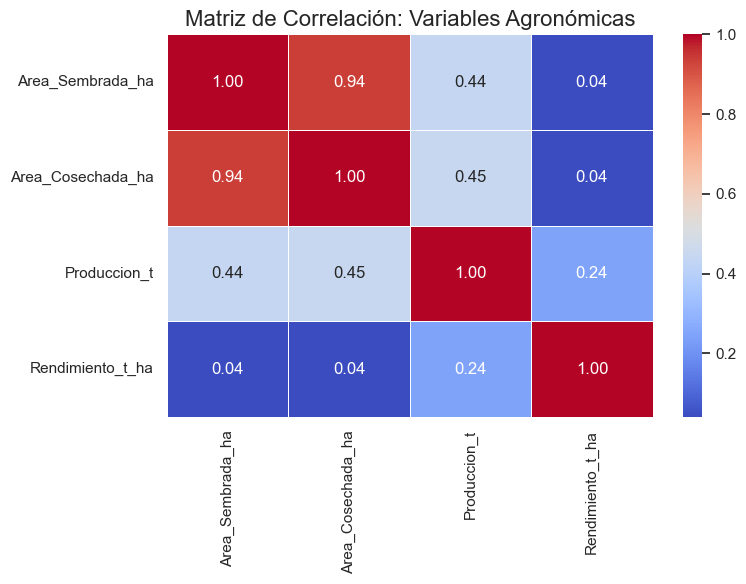

In [29]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_unificado[cols_numericas].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Variables Agronómicas', fontsize=16)
plt.tight_layout()
plt.show()

### GRÁFICO 2: Producción a lo largo del tiempo vs Área cosechada (Serie de Tiempo)

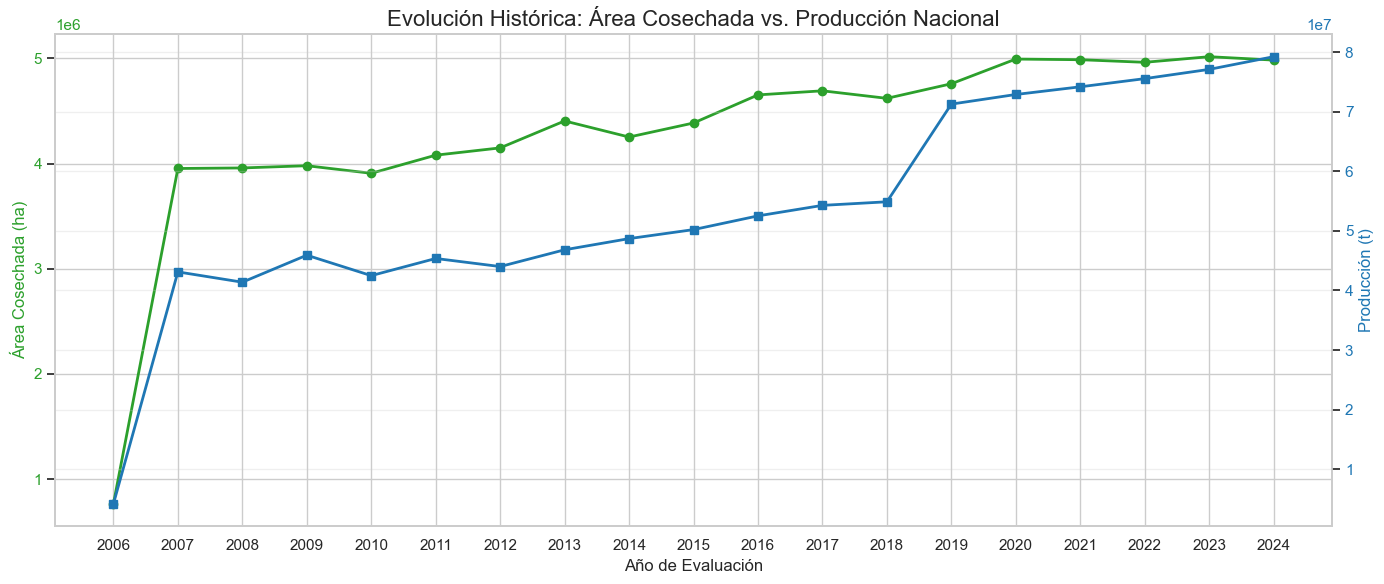

In [30]:
# Evolución anual del área cosechada vs producción
evolucion_anual = df_unificado.groupby('Anio')[['Area_Cosechada_ha', 'Produccion_t']].sum().reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.set_xlabel('Año de Evaluación', fontsize=12)
ax1.set_ylabel('Área Cosechada (ha)', color='tab:green', fontsize=12)
ax1.plot(evolucion_anual['Anio'], evolucion_anual['Area_Cosechada_ha'], color='tab:green', marker='o', linewidth=2, label='Área Cosechada')
ax1.tick_params(axis='y', labelcolor='tab:green')
ax1.set_xticks(evolucion_anual['Anio'].unique()) # Mostrar todos los años

ax2 = ax1.twinx()  
ax2.set_ylabel('Producción (t)', color='tab:blue', fontsize=12)
ax2.plot(evolucion_anual['Anio'], evolucion_anual['Produccion_t'], color='tab:blue', marker='s', linewidth=2, label='Producción')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Evolución Histórica: Área Cosechada vs. Producción Nacional', fontsize=16)
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()


### GRÁFICO 3: Top 10 Cultivos más sembrados históricamente y Areas sembradas por ciclo

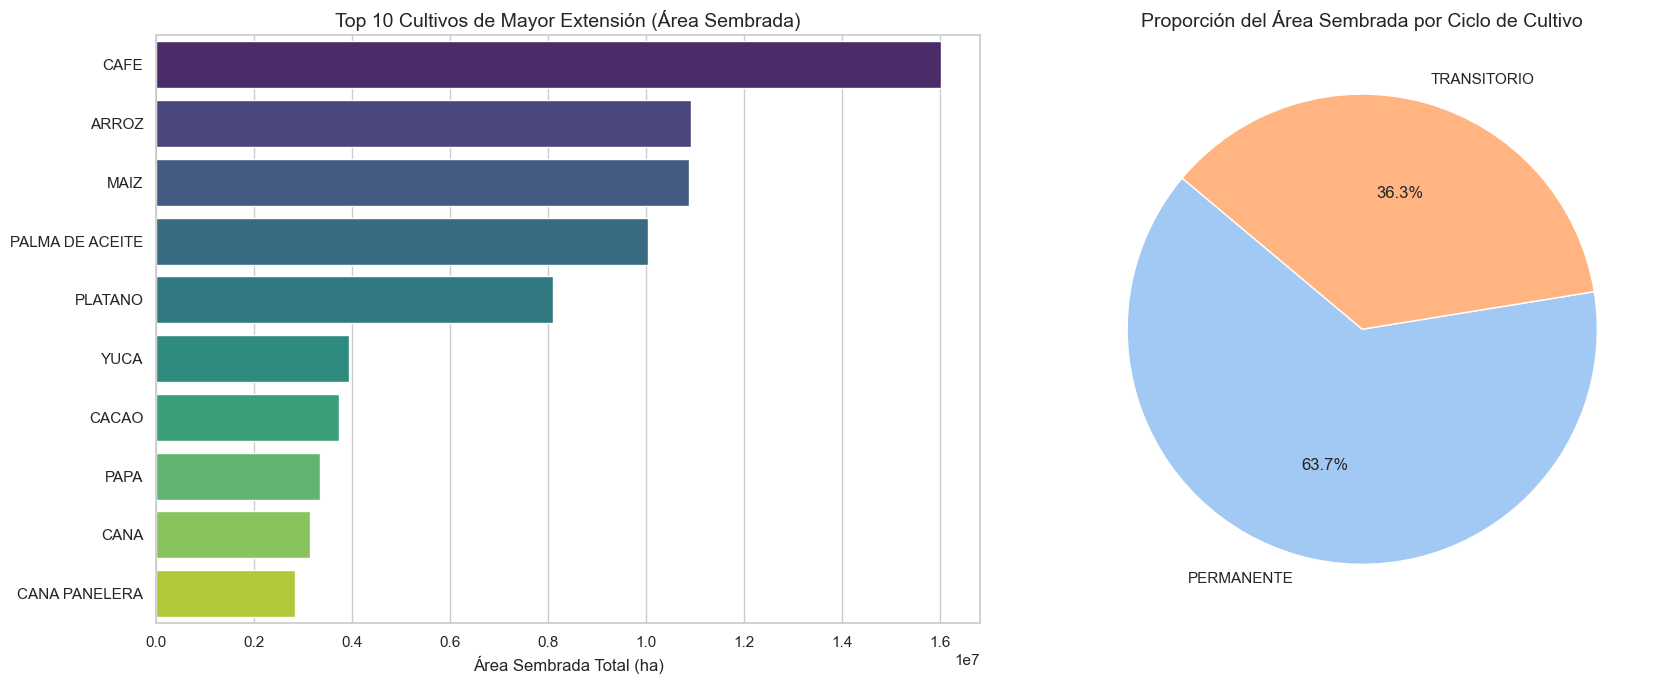

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Top 10 Cultivos por Área Sembrada
top_cultivos = df_unificado.groupby('Cultivo')['Area_Sembrada_ha'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_cultivos.values, y=top_cultivos.index, palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Cultivos de Mayor Extensión (Área Sembrada)', fontsize=14)
axes[0].set_xlabel('Área Sembrada Total (ha)')
axes[0].set_ylabel('')

# 2. Proporción de Área Sembrada por Ciclo de Cultivo
ciclos = df_unificado.groupby('Ciclo_Cultivo')['Area_Sembrada_ha'].sum()
axes[1].pie(ciclos.values, labels=ciclos.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1].set_title('Proporción del Área Sembrada por Ciclo de Cultivo', fontsize=14)

plt.tight_layout()
plt.show()

### GRÁFICO 4: Distribución de Rendimiento por Ciclo de Cultivo

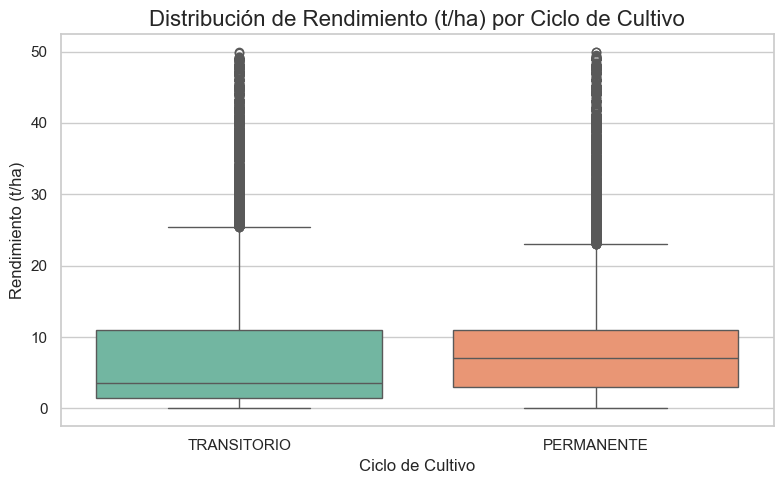

In [32]:
# Filtramos rendimientos atípicos extremos para mejor visualización en el boxplot (ej. < 50 t/ha)
df_boxplot = df_unificado[df_unificado['Rendimiento_t_ha'] < 50]
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_boxplot, x='Ciclo_Cultivo', y='Rendimiento_t_ha', palette='Set2')
plt.title('Distribución de Rendimiento (t/ha) por Ciclo de Cultivo', fontsize=16)
plt.xlabel('Ciclo de Cultivo', fontsize=12)
plt.ylabel('Rendimiento (t/ha)', fontsize=12)
plt.tight_layout()
plt.show()

### GRÁFICO 5: Análisis Geográfico (Departamentos)

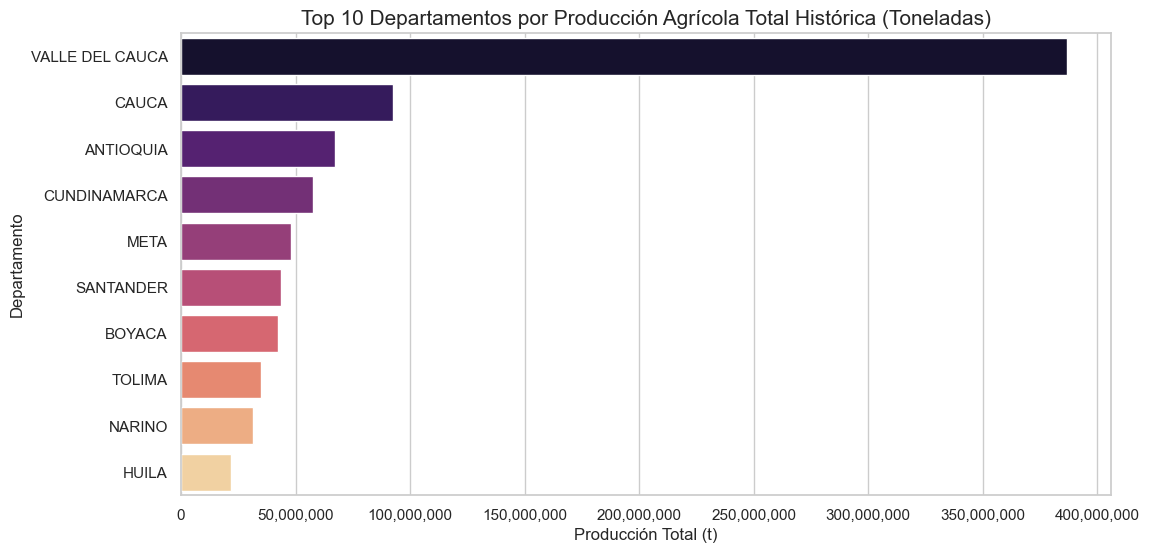

In [33]:
# Top 10 Departamentos con mayor Producción Total Histórica
top_deptos = df_unificado.groupby('Departamento')['Produccion_t'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_deptos.values, y=top_deptos.index, palette='magma')
plt.title('Top 10 Departamentos por Producción Agrícola Total Histórica (Toneladas)', fontsize=15)
plt.xlabel('Producción Total (t)')
plt.ylabel('Departamento')

# Formatear el eje X para leer millones fácilmente
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.show()

#Cod_Dep,Departamento,Cod_Mun,Municipio,Grupo_Cultivo,Subgrupo_Cultivo,Cultivo,Anio,Periodo,Area_Sembrada_ha,Area_Cosechada_ha,
#Produccion_t,Rendimiento_t_ha,Ciclo_Cultivo,Semestre

### GRÁFICO 6: Comparativa por Semestre

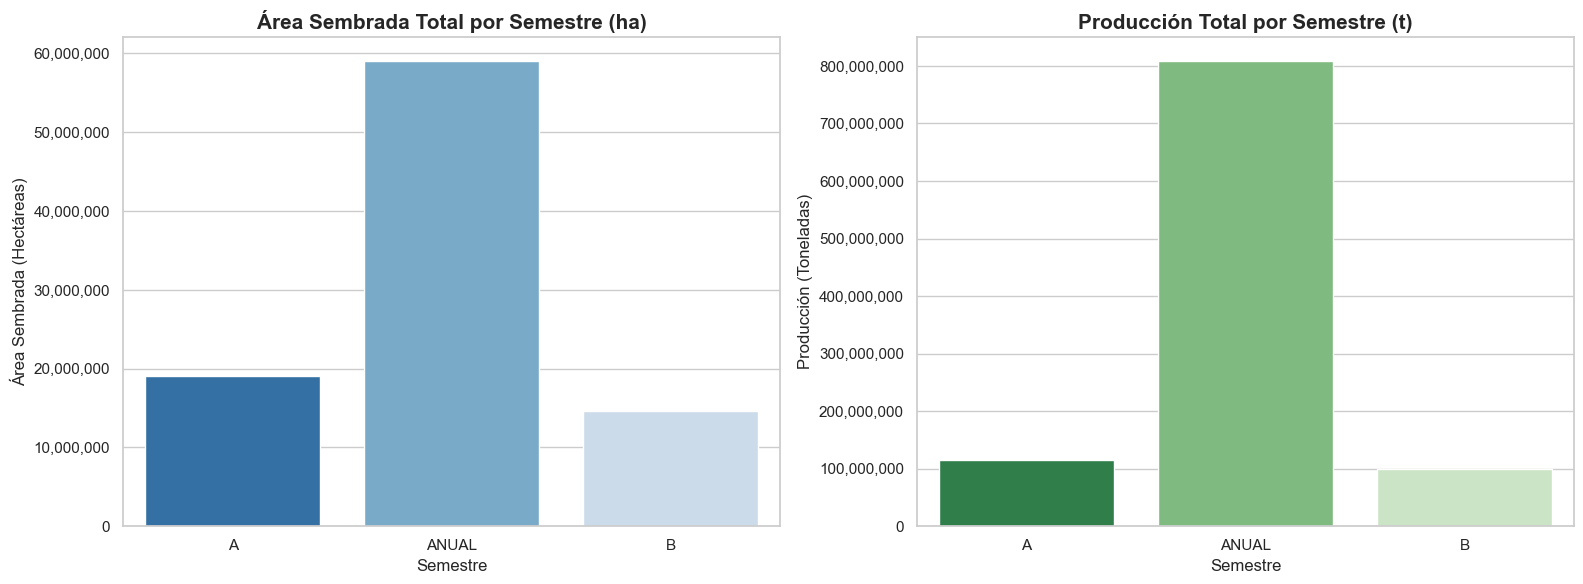


--- Resumen Numérico por Semestre ---


,Semestre,Area_Sembrada_ha,Produccion_t
0,A,"19,099,010","114,996,295"
1,ANUAL,"59,096,151","809,209,311"
2,B,"14,631,040","100,058,561"


In [34]:
# Agrupar los datos por 'Semestre' y calcular los totales
df_semestre = df_unificado.groupby('Semestre')[['Area_Sembrada_ha', 'Produccion_t']].sum().reset_index()

# Configurar la figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Subgráfico 1: Área Sembrada ---
sns.barplot(data=df_semestre, x='Semestre', y='Area_Sembrada_ha', ax=axes[0], palette='Blues_r')
axes[0].set_title('Área Sembrada Total por Semestre (ha)', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Semestre', fontsize=12)
axes[0].set_ylabel('Área Sembrada (Hectáreas)', fontsize=12)

# Formatear el eje Y para que no use notación científica (ej. 1e6)
axes[0].ticklabel_format(style='plain', axis='y')
# Opcional: Agregar separador de miles para facilitar la lectura
axes[0].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# --- Subgráfico 2: Producción ---
sns.barplot(data=df_semestre, x='Semestre', y='Produccion_t', ax=axes[1], palette='Greens_r')
axes[1].set_title('Producción Total por Semestre (t)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Semestre', fontsize=12)
axes[1].set_ylabel('Producción (Toneladas)', fontsize=12)

# Formatear el eje Y
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()

# Imprimir un pequeño resumen numérico para tener el dato exacto
print("\n--- Resumen Numérico por Semestre ---")
display(df_semestre.style.format({'Area_Sembrada_ha': '{:,.0f}', 'Produccion_t': '{:,.0f}'}))